Import Libraries

In [47]:
# Step 1: Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

Load Dataset

In [48]:
# Step 2: Load dataset

column_names = ['Sex', 'Length', 'Diameter', 'Height', 'Whole_weight',
                'Shucked_weight', 'Viscera_weight', 'Shell_weight', 'Rings']

df = pd.read_csv("abalone.csv", names=column_names, index_col=False)

# Display first 5 rows
df.head()

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


Basic Info

In [49]:
# Step 3: Dataset information

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4177 non-null   object 
 1   Length          4177 non-null   float64
 2   Diameter        4177 non-null   float64
 3   Height          4177 non-null   float64
 4   Whole_weight    4177 non-null   float64
 5   Shucked_weight  4177 non-null   float64
 6   Viscera_weight  4177 non-null   float64
 7   Shell_weight    4177 non-null   float64
 8   Rings           4177 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 293.8+ KB


,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
count,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000
mean,0.523992,0.407881,0.139516,0.828742,0.359367,0.180594,0.238831,9.933684
std,0.120093,0.099240,0.041827,0.490389,0.221963,0.109614,0.139203,3.224169
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,0.450000,0.350000,0.115000,0.441500,0.186000,0.093500,0.130000,8.000000
50%,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.234000,9.000000
75%,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.329000,11.000000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


Check Missing Values

In [50]:
# Step 4: Check missing values

df.isnull().sum()

,0
Sex,0
Length,0
Diameter,0
Height,0
Whole_weight,0
Shucked_weight,0
Viscera_weight,0
Shell_weight,0
Rings,0


Handle Abnormal Values ("3+")

In [51]:
# Step 5: Handle abnormal values like "3+"

df = df.replace("3+", 3)

# Convert numeric columns
numeric_cols = ['Length', 'Diameter', 'Height', 'Whole_weight',
                'Shucked_weight', 'Viscera_weight', 'Shell_weight', 'Rings']

df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

Drop Missing Values

In [52]:
# Step 6: Drop missing values

df = df.dropna()

Encode Categorical Variable

In [53]:
# Step 7: Encode 'Sex' column

df = pd.get_dummies(df, columns=['Sex'])

Exploratory Data Analysis (EDA)

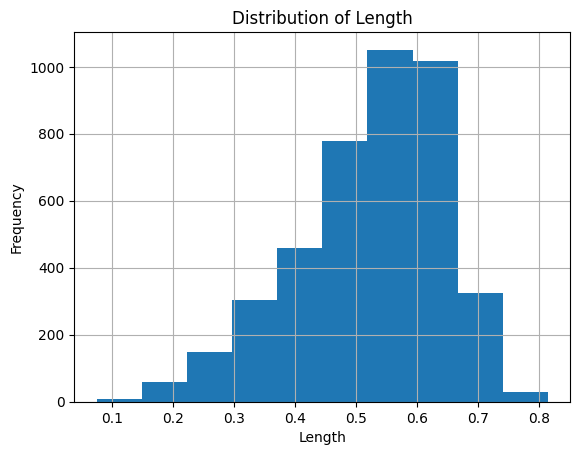

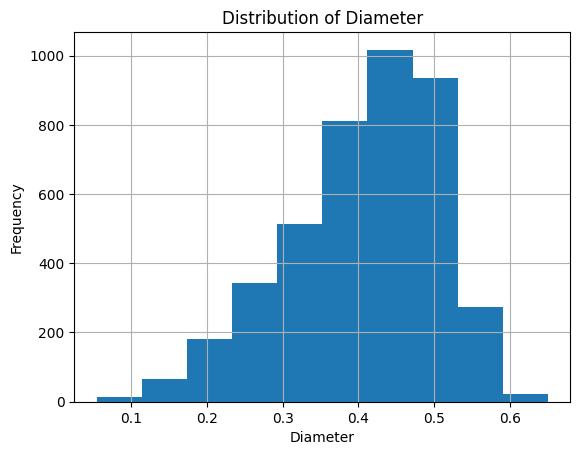

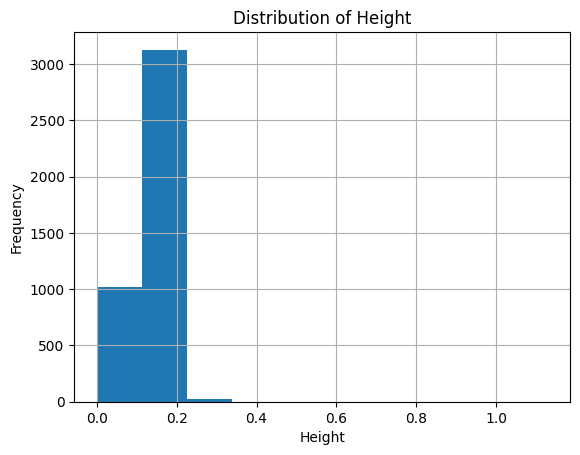

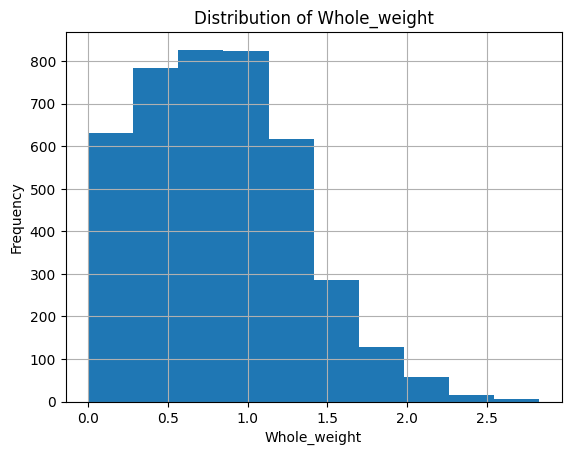

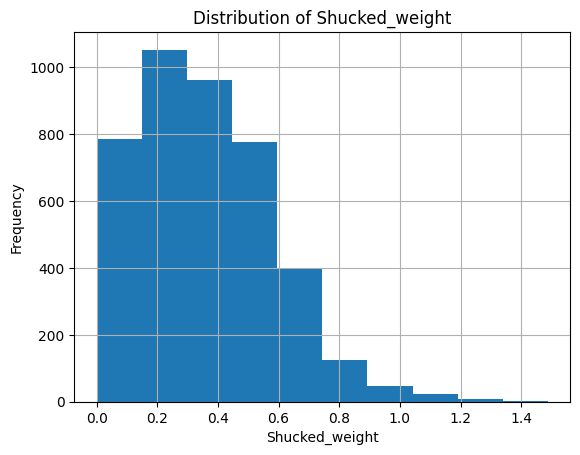

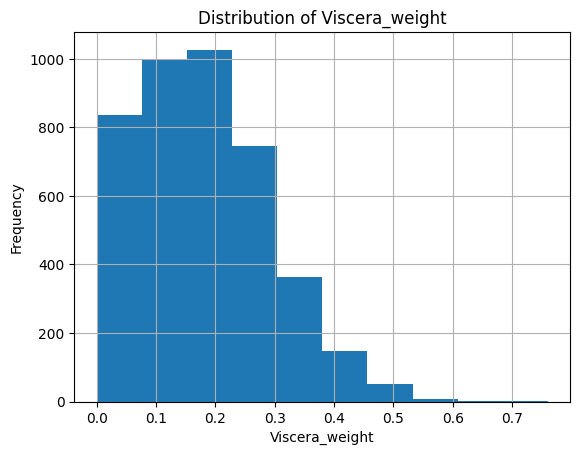

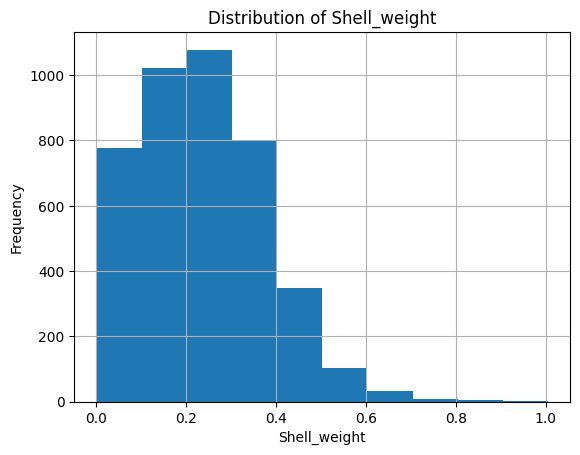

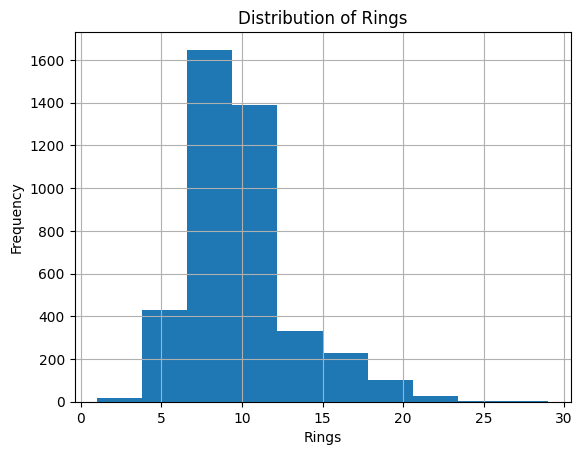

In [54]:
# Step 8: Exploratory Data Analysis (one plot per variable)

for col in df.select_dtypes(include=np.number).columns:
    plt.figure()
    df[col].hist()
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

Define Features and Target

In [55]:
# Step 9: Define X (features) and y (target)

X = df.drop('Rings', axis=1)
y = df['Rings']

Train-Test Split

In [56]:
# Step 10: Split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Build Model

In [57]:
# Step 11: Build Random Forest model

model = RandomForestRegressor(random_state=42)

Train Model

In [58]:
# Step 12: Train model

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

Test Model

In [59]:
# Step 13: Test model performance

y_pred = model.predict(X_test)

print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

Mean Squared Error: 5.089339114832536
R2 Score: 0.5298623219859746


10-Fold Cross Validation

In [60]:
# Step 14: Cross-validation

cv_scores = cross_val_score(model, X, y, cv=10)

print("Cross-validation scores:", cv_scores)
print("Average CV score:", np.mean(cv_scores))

Cross-validation scores: [0.51516904 0.39655958 0.4074091  0.0483946  0.26437802 0.49423341
 0.45793396 0.4591267  0.54802501 0.4420274 ]
Average CV score: 0.4033256822779305


Create Two New Records

In [61]:
# Step 15: Create new data records

new_data = pd.DataFrame([
    [0.55, 0.45, 0.15, 1.2, 0.6, 0.3, 0.35, 1, 0, 0],
    [0.35, 0.25, 0.08, 0.5, 0.2, 0.1, 0.15, 0, 1, 0]
], columns=X.columns)

Predict Age

In [62]:
# Step 16: Predict Rings and Age

predictions = model.predict(new_data)

for i, pred in enumerate(predictions):
    age = pred + 1.5
    print(f"Record {i+1}: Predicted Rings = {pred:.2f}, Predicted Age = {age:.2f} years")

Record 1: Predicted Rings = 10.24, Predicted Age = 11.74 years
Record 2: Predicted Rings = 9.56, Predicted Age = 11.06 years
